### So now you have understood how decision tree works now it's your time to practice it

### **Import all the required libraries.**

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Load the file using pandas.**

In [4]:
df = pd.read_csv('drug200(DT).csv')

### **Perform some basic EDA like peeking top and bottom rows ,checking types of columns, viewing columns**

In [5]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64
              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std   

### **Count which gender is present most in the  dataset**

C:\Users\Tanishq Vyas\AppData\Local\Temp\ipykernel_9020\3801968485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='Set2')


<Axes: xlabel='Sex', ylabel='count'>

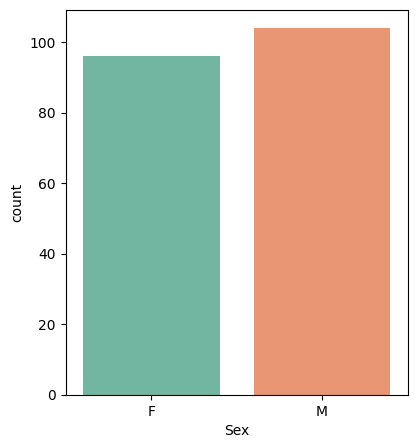

In [6]:
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Sex', palette='Set2')


### **Plot a bar chart showing counts of each category in the Sex column using Seaborn with the Set2 color palette.**

C:\Users\Tanishq Vyas\AppData\Local\Temp\ipykernel_9020\81708436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='BP', palette='Set3')


<Axes: title={'center': 'Sex Distribution'}, xlabel='BP', ylabel='count'>

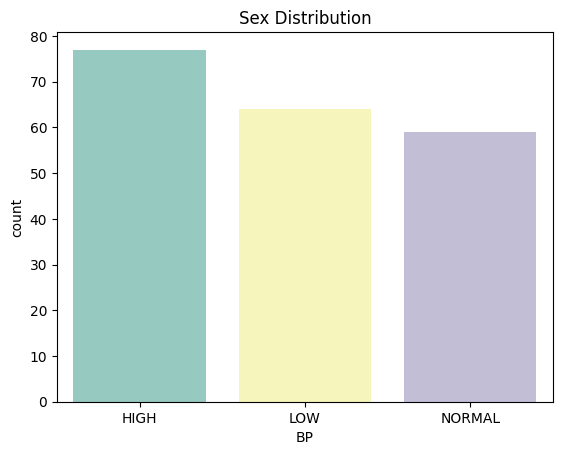

In [2]:
plt.title('Sex Distribution')
sns.countplot(data=df, x='BP', palette='Set3')

### **Plot a countplot showing counts of each category in the Cholesterol column using Seaborn with the Set1 color palette.**

C:\Users\Tanishq Vyas\AppData\Local\Temp\ipykernel_9020\810850346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cholesterol', palette='Set1')


<Axes: title={'center': 'BP Distribution'}, xlabel='Cholesterol', ylabel='count'>

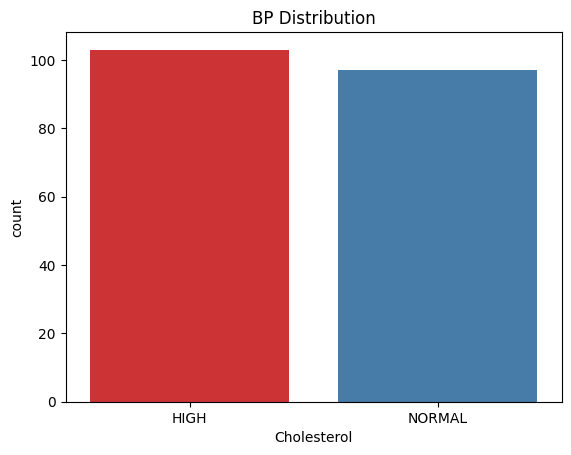

In [9]:
plt.title('BP Distribution')
sns.countplot(data=df, x='Cholesterol', palette='Set1')

### Let's plot a heatmap to visualize how all numerical features in the dataset are correlated with each other

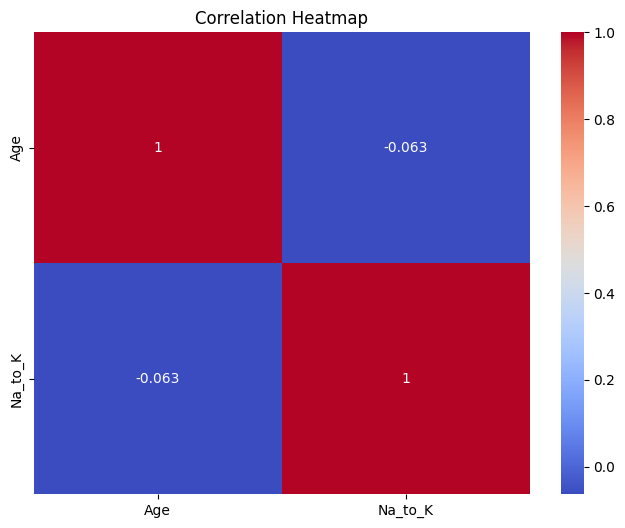

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



### Encoding Categorical Variables

We use `LabelEncoder`from sklearn.preprocessing to **convert categorical text columns into numeric values**, which allows machine learning models to process them.  

In [11]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex'])
df['BP'] = label.fit_transform(df['BP'])
df['Cholesterol'] = label.fit_transform(df['Cholesterol'])
df['Drug'] = label.fit_transform(df['Drug'])

### Splitting Data and Training a Decision Tree Classifier

**Separate features and target:**
Here `Drug` is our target feature 


In [ ]:
X = df.drop('Drug', axis=1)
y = df['Drug']





## **Splitting Data into Train and Test Sets**
train_test_split() from sklearn.model_selection



Training set (80%) → used to train the model

Testing set (20%) → used to evaluate the modelbrary.


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



**We initialize a Decision Tree Classifier with entropy as the criterion, a maximum depth of 3, and default values for min_samples_leaf and min_samples_split, while fixing random_state=42 for reproducibility.**
we can get `DecisionTreeClassifier` from `sklearn.trees`

In [17]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy', splitter='best', max_features=5, max_depth=3)

## **Training the Model**

In [19]:
model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,5
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


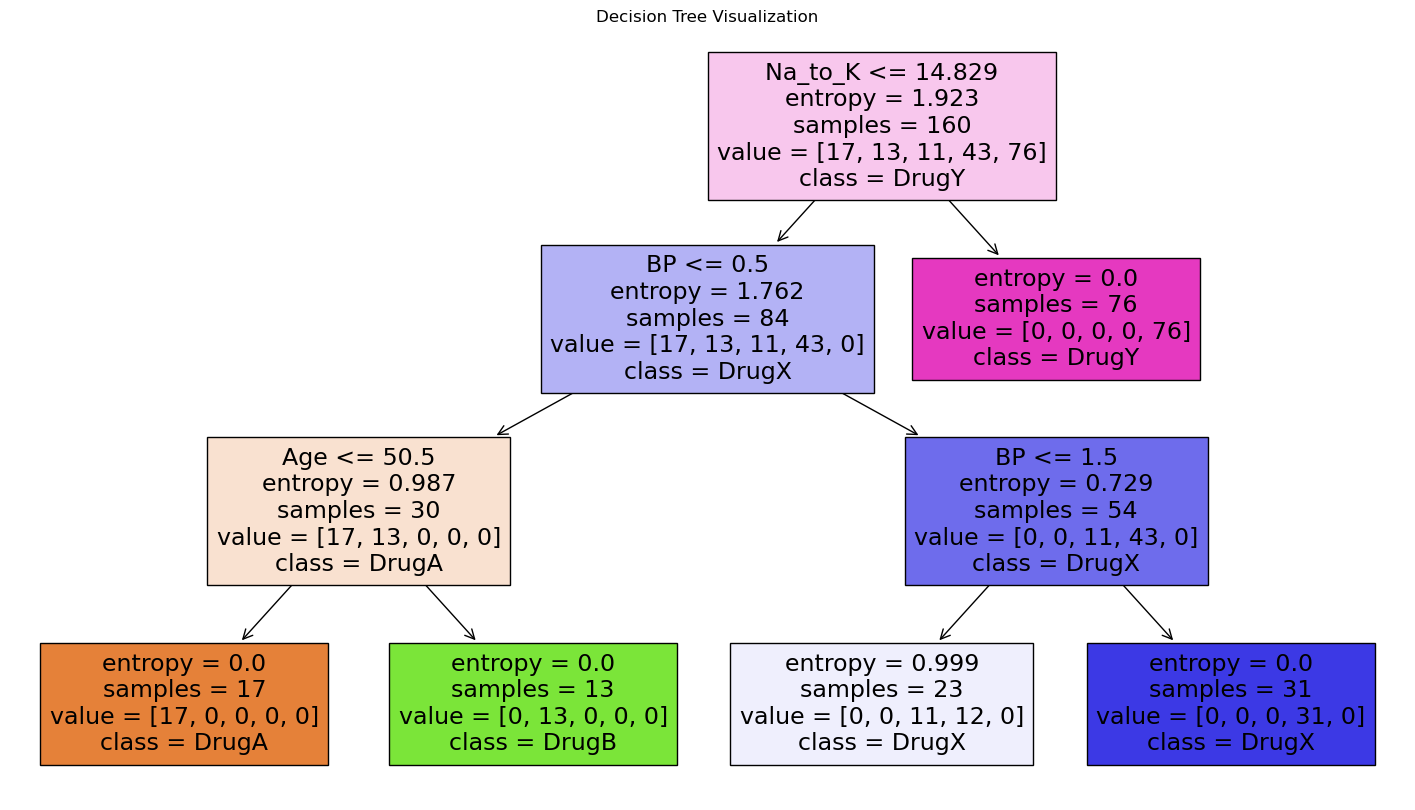

In [78]:
plt.figure(figsize=(18,10))
plot_tree(model, feature_names=x_var.columns, class_names=['DrugA','DrugB','DrugC','DrugX','DrugY'], filled=True)
plt.title('Decision Tree Visualization')
plt.show()

**After training it's time for making prediciton on our  model**

In [20]:
y_pred = model.predict(X_test)

**After making predicition we have to check how good our model is performing after making prediction**

In [24]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test, y_pred)*100)


87.5
